In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import xgboost as xgb

# Set display options
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 80)
plt.style.use('seaborn-v0_8-whitegrid')

# Load data
train_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
train_data.head()

Train shape: (198000, 15)
Test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [3]:
print("\n Basic Info:")
print(f"   - Total training samples: {len(train_data):,}")
print(f"   - Total test samples: {len(test_data):,}")
print(f"   - Number of features: {train_data.shape[1]}")
print(f"   - Memory usage: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Column Types:")
print(train_data.dtypes)


 Basic Info:
   - Total training samples: 198,000
   - Total test samples: 102,000
   - Number of features: 15
   - Memory usage: 121.09 MB

 Column Types:
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


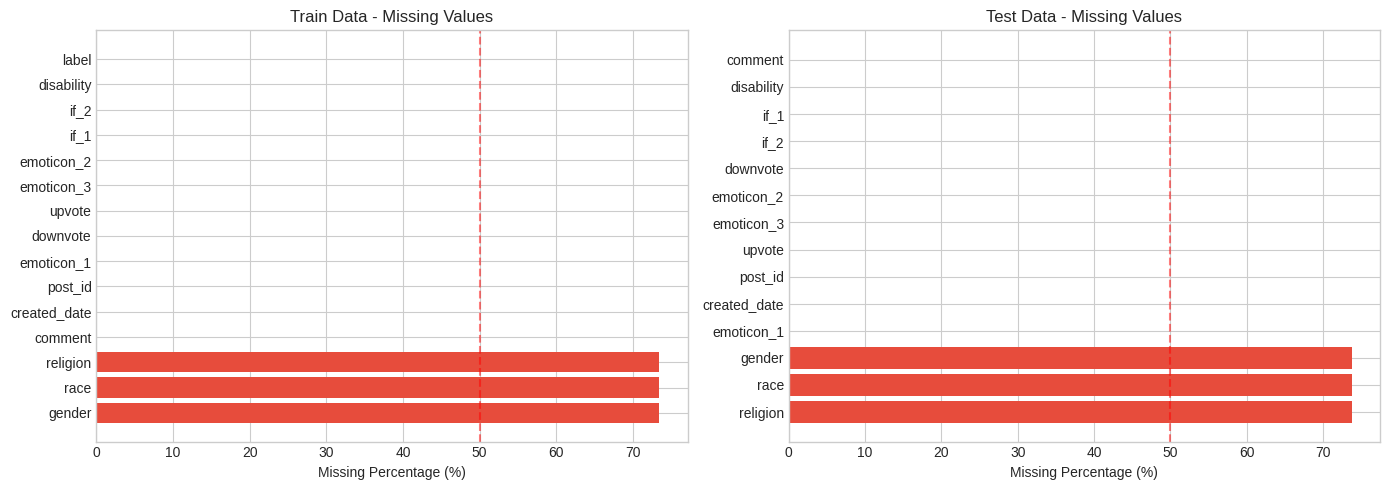

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train missing values
missing_train = train_data.isnull().sum()
missing_train_pct = (missing_train / len(train_data) * 100).round(2)
missing_df_train = pd.DataFrame({
    'Column': missing_train.index,
    'Missing': missing_train.values,
    'Percentage': missing_train_pct.values
}).sort_values('Missing', ascending=False)

colors_train = ['#e74c3c' if x > 0 else '#2ecc71' for x in missing_df_train['Missing']]
axes[0].barh(missing_df_train['Column'], missing_df_train['Percentage'], color=colors_train)
axes[0].set_xlabel('Missing Percentage (%)')
axes[0].set_title('Train Data - Missing Values')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')

# Test missing values
missing_test = test_data.isnull().sum()
missing_test_pct = (missing_test / len(test_data) * 100).round(2)
missing_df_test = pd.DataFrame({
    'Column': missing_test.index,
    'Missing': missing_test.values,
    'Percentage': missing_test_pct.values
}).sort_values('Missing', ascending=False)

colors_test = ['#e74c3c' if x > 0 else '#2ecc71' for x in missing_df_test['Missing']]
axes[1].barh(missing_df_test['Column'], missing_df_test['Percentage'], color=colors_test)
axes[1].set_xlabel('Missing Percentage (%)')
axes[1].set_title('Test Data - Missing Values')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

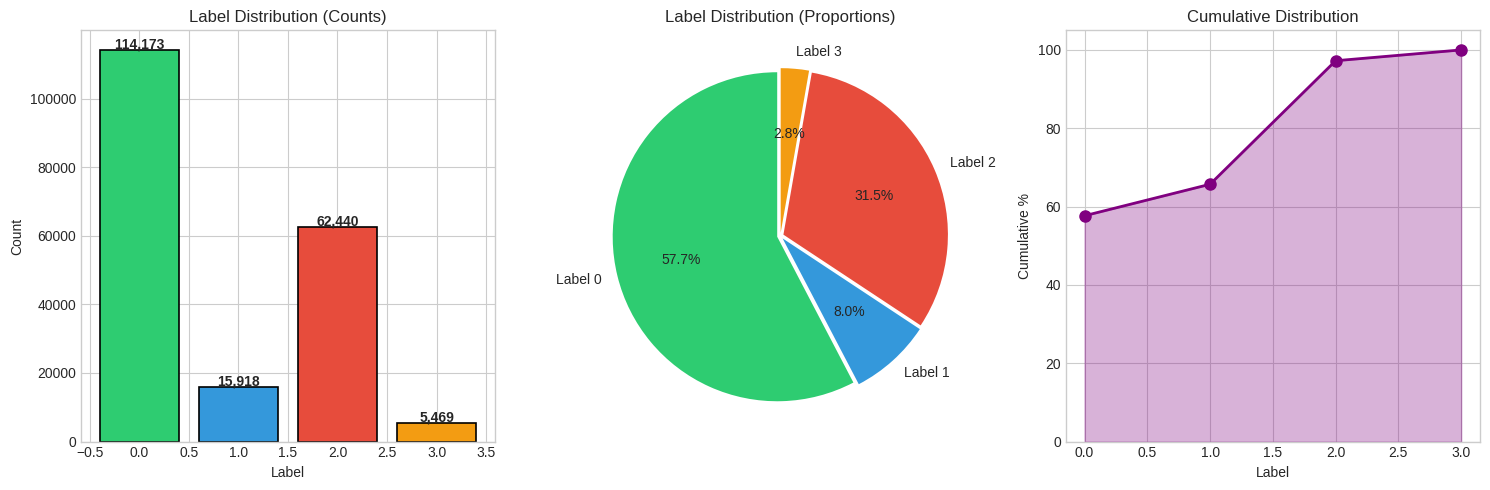


⚠️ Class Imbalance Detected:
   - Label 0 (majority): 114,173 samples (57.7%)
   - Label 3 (minority): 5,469 samples (2.8%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

label_counts = train_data['label'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

# Bar chart
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution (Counts)')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=[f'Label {i}' for i in label_counts.index], 
            autopct='%1.1f%%', colors=colors, explode=[0.02]*4, startangle=90)
axes[1].set_title('Label Distribution (Proportions)')

# Cumulative distribution
cumsum = label_counts.cumsum() / label_counts.sum() * 100
axes[2].plot(label_counts.index, cumsum, marker='o', linewidth=2, markersize=8, color='purple')
axes[2].fill_between(label_counts.index, cumsum, alpha=0.3, color='purple')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Cumulative %')
axes[2].set_title('Cumulative Distribution')
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("\n⚠️ Class Imbalance Detected:")
print(f"   - Label 0 (majority): {label_counts[0]:,} samples ({label_counts[0]/len(train_data)*100:.1f}%)")
print(f"   - Label 3 (minority): {label_counts[3]:,} samples ({label_counts[3]/len(train_data)*100:.1f}%)")

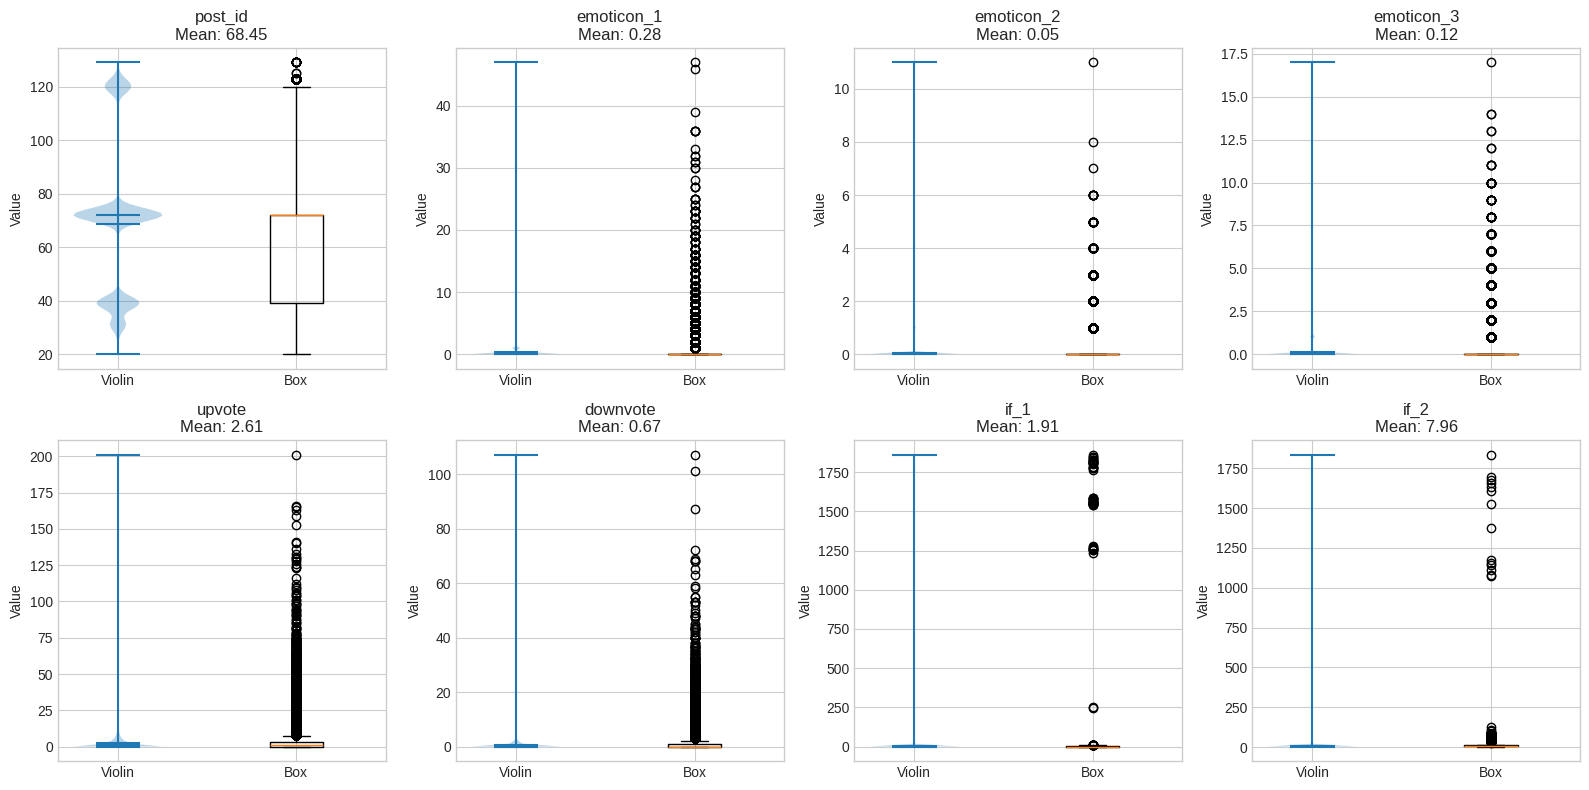


📈 Statistical Summary:
             mean    std   min   50%     max
post_id     68.45  27.95  20.0  72.0   129.0
emoticon_1   0.28   1.02   0.0   0.0    47.0
emoticon_2   0.05   0.26   0.0   0.0    11.0
emoticon_3   0.12   0.48   0.0   0.0    17.0
upvote       2.61   5.05   0.0   1.0   201.0
downvote     0.67   2.04   0.0   0.0   107.0
if_1         1.91  25.64   0.0   0.0  1860.0
if_2         7.96  14.84   3.0   6.0  1833.0


In [6]:
numeric_cols = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
                'upvote', 'downvote', 'if_1', 'if_2']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data = train_data[col].dropna()
    axes[idx].violinplot(data, positions=[0], showmeans=True, showmedians=True)
    axes[idx].boxplot(data, positions=[1], widths=0.3)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Violin', 'Box'])
    axes[idx].set_title(f'{col}\nMean: {data.mean():.2f}')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

print("\n📈 Statistical Summary:")
print(train_data[numeric_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

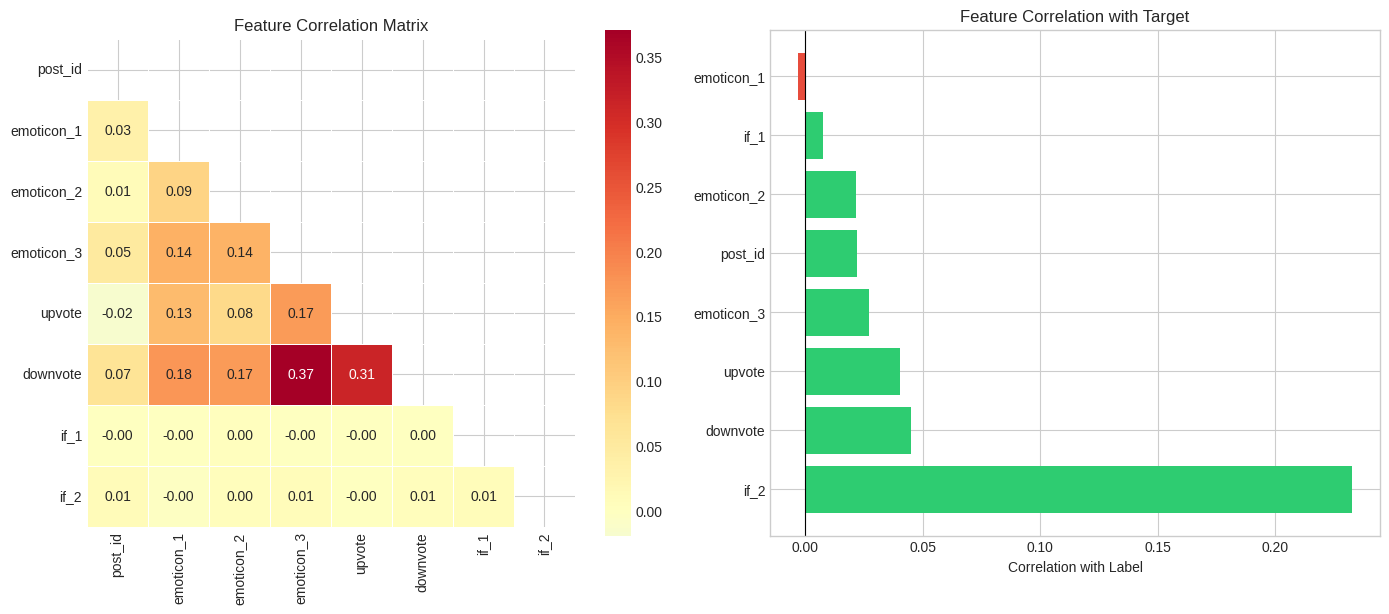

In [7]:
numeric_features = train_data.select_dtypes(include=[np.number]).drop(columns=['label'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Correlation heatmap
corr_matrix = numeric_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontsize=12)

# Correlation with target
target_corr = train_data[numeric_features.columns.tolist() + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
axes[1].barh(range(len(target_corr)), target_corr.values, color=colors)
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index)
axes[1].set_xlabel('Correlation with Label')
axes[1].set_title('Feature Correlation with Target')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

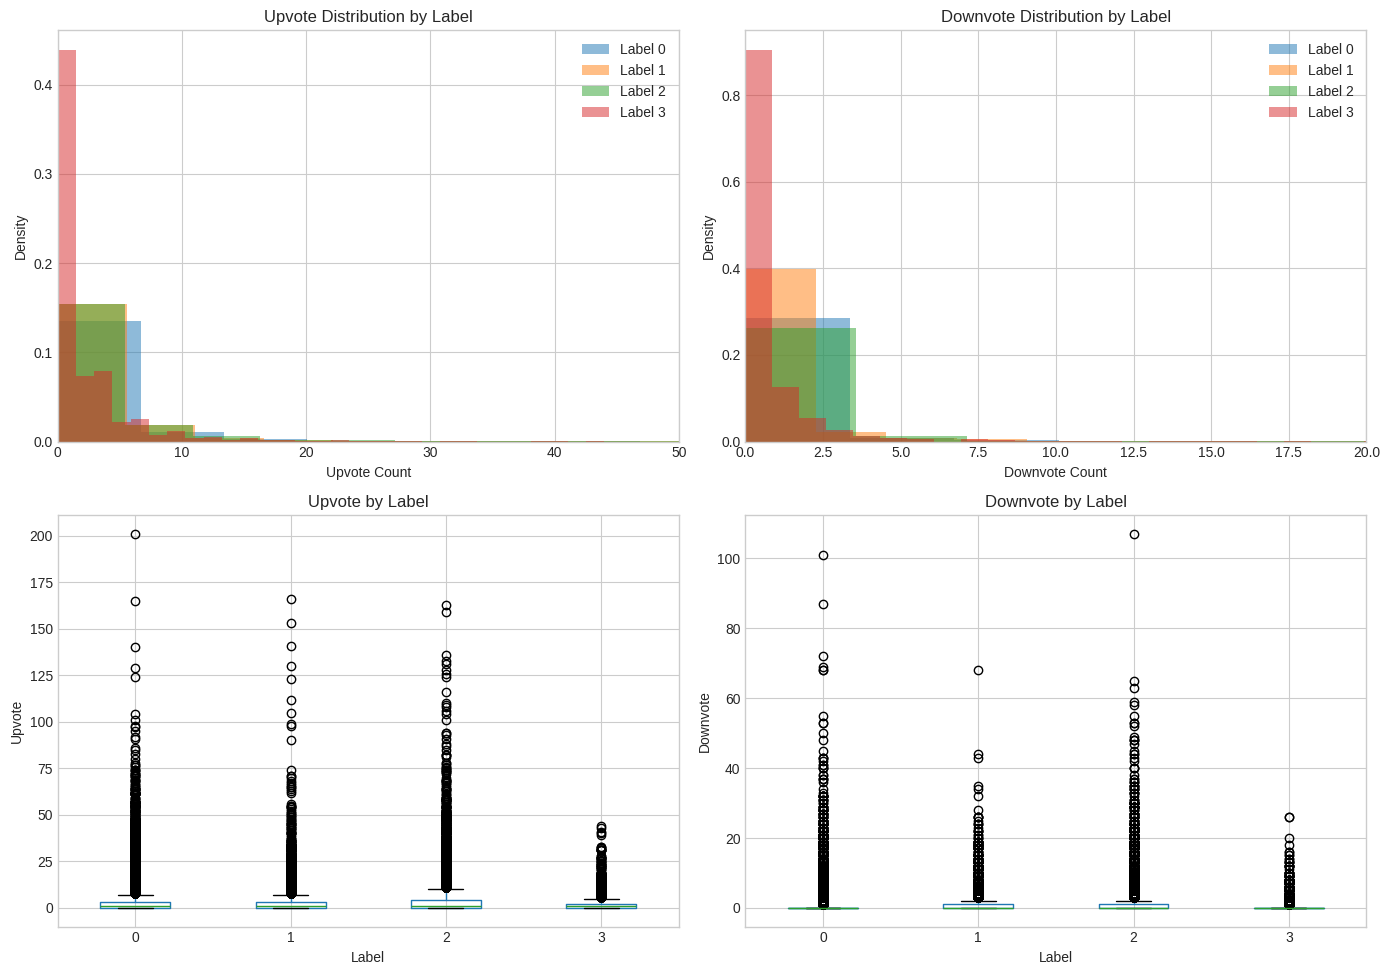


 Vote Statistics by Label:
      upvote              downvote             
        mean median   std     mean median   std
label                                          
0       2.40    1.0  4.60     0.58    0.0  1.86
1       2.85    1.0  6.05     0.80    0.0  2.17
2       2.97    1.0  5.61     0.81    0.0  2.34
3       2.04    1.0  3.77     0.51    0.0  1.52


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Upvote distribution by label
for label in sorted(train_data['label'].unique()):
    subset = train_data[train_data['label'] == label]['upvote']
    axes[0, 0].hist(subset, bins=30, alpha=0.5, label=f'Label {label}', density=True)
axes[0, 0].set_xlabel('Upvote Count')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Upvote Distribution by Label')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 50)

# Downvote distribution by label
for label in sorted(train_data['label'].unique()):
    subset = train_data[train_data['label'] == label]['downvote']
    axes[0, 1].hist(subset, bins=30, alpha=0.5, label=f'Label {label}', density=True)
axes[0, 1].set_xlabel('Downvote Count')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Downvote Distribution by Label')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 20)

# Box plots
train_data.boxplot(column='upvote', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Upvote by Label')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Upvote')
plt.suptitle('')

train_data.boxplot(column='downvote', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Downvote by Label')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Downvote')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n Vote Statistics by Label:")
print(train_data.groupby('label')[['upvote', 'downvote']].agg(['mean', 'median', 'std']).round(2))

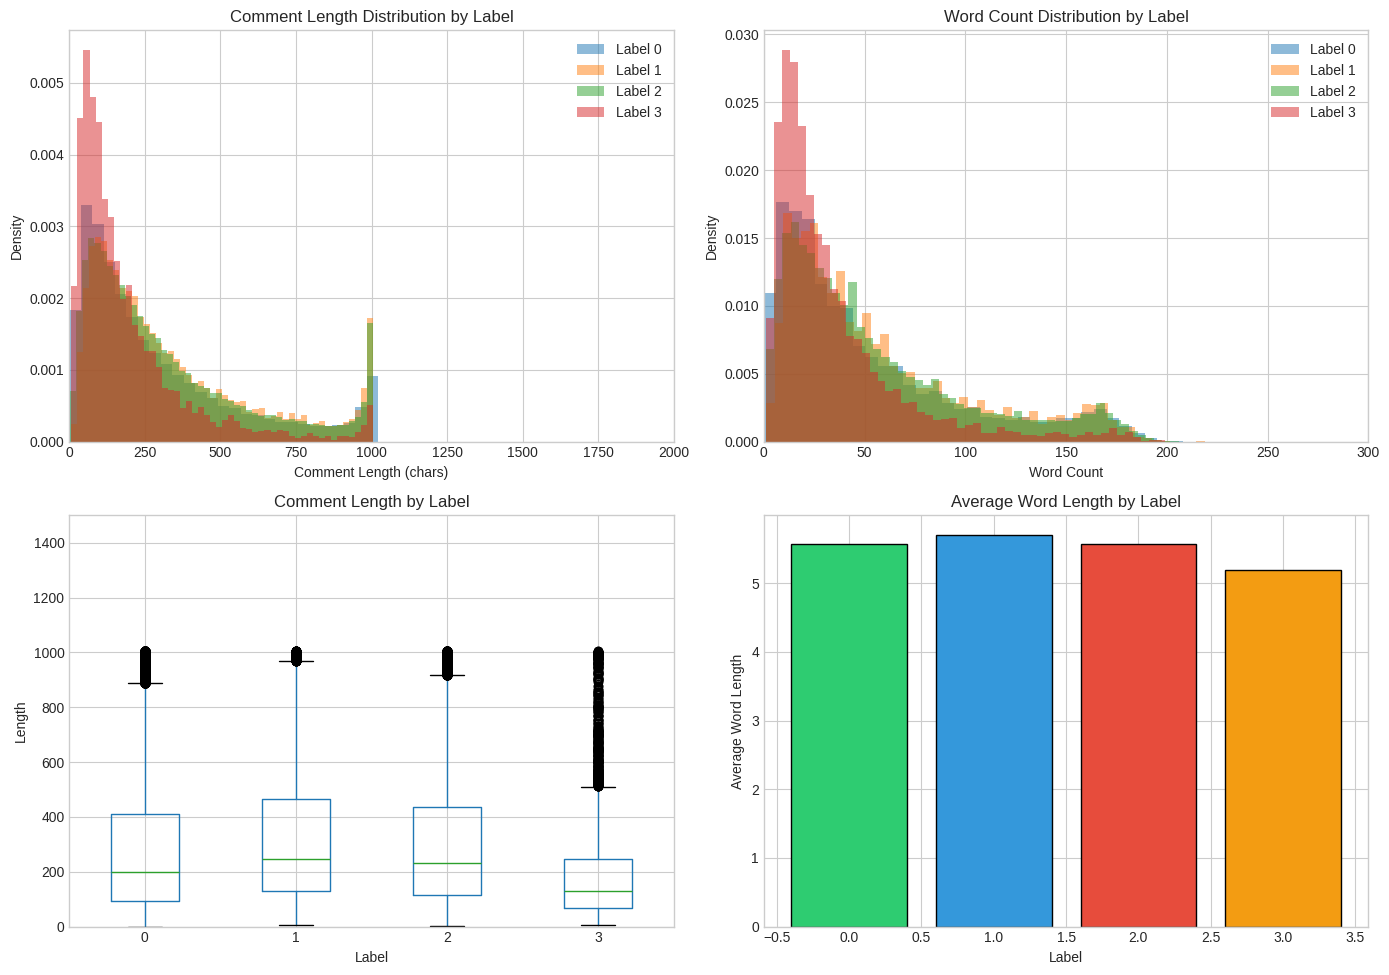

In [9]:
# Calculate text features
train_data['comment_length'] = train_data['comment'].fillna('').str.len()
train_data['word_count'] = train_data['comment'].fillna('').str.split().str.len()
train_data['avg_word_length'] = train_data['comment_length'] / (train_data['word_count'] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Comment length distribution
for label in sorted(train_data['label'].unique()):
    subset = train_data[train_data['label'] == label]['comment_length']
    axes[0, 0].hist(subset, bins=50, alpha=0.5, label=f'Label {label}', density=True)
axes[0, 0].set_xlabel('Comment Length (chars)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Comment Length Distribution by Label')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 2000)

# Word count distribution
for label in sorted(train_data['label'].unique()):
    subset = train_data[train_data['label'] == label]['word_count']
    axes[0, 1].hist(subset, bins=50, alpha=0.5, label=f'Label {label}', density=True)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Word Count Distribution by Label')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 300)

# Box plot
train_data.boxplot(column='comment_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Comment Length by Label')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Length')
axes[1, 0].set_ylim(0, 1500)
plt.suptitle('')

# Average word length
avg_word_len = train_data.groupby('label')['avg_word_length'].mean()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
axes[1, 1].bar(avg_word_len.index, avg_word_len.values, color=colors, edgecolor='black')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Average Word Length')
axes[1, 1].set_title('Average Word Length by Label')

plt.tight_layout()
plt.show()

In [10]:
def clean_text(text):
    """Clean and normalize text"""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s!?.]', ' ', text)  # Keep alphanumeric and punctuation
    return re.sub(r'\s+', ' ', text).strip()


def engineer_features(df):
    """Create comprehensive features from raw data"""
    df = df.copy()
    df['comment'] = df['comment'].fillna('')
    df['comment_clean'] = df['comment'].apply(clean_text)

    # Convert columns to numeric
    for col in ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3',
                'race', 'religion', 'gender', 'disability', 'if_1', 'if_2']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


    # TEXT STATISTICS
    df['comment_length'] = df['comment'].str.len()
    df['word_count'] = df['comment'].str.split().str.len().fillna(0).astype(int)
    df['avg_word_length'] = df['comment_length'] / (df['word_count'] + 1)
    df['uppercase_ratio'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['special_char_count'] = df['comment'].apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))
    df['exclamation_count'] = df['comment'].str.count('!')
    df['question_count'] = df['comment'].str.count(r'\?')
    
    # Advanced text features
    df['digit_count'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isdigit()))
    df['caps_words_count'] = df['comment'].apply(lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
    df['unique_word_ratio'] = df['comment'].apply(lambda x: len(set(x.lower().split())) / (len(x.split()) + 1))
    df['punctuation_density'] = df['special_char_count'] / (df['comment_length'] + 1)
    

    # SENTIMENT PROXY FEATURES
    positive_words = ['good', 'great', 'love', 'best', 'awesome', 'excellent', 'happy', 'nice', 'beautiful', 'wonderful']
    negative_words = ['bad', 'hate', 'worst', 'terrible', 'awful', 'horrible', 'stupid', 'wrong', 'evil', 'disgusting']
    df['positive_word_count'] = df['comment_clean'].apply(lambda x: sum(1 for w in x.split() if w in positive_words))
    df['negative_word_count'] = df['comment_clean'].apply(lambda x: sum(1 for w in x.split() if w in negative_words))
    df['sentiment_ratio'] = (df['positive_word_count'] - df['negative_word_count']) / (df['word_count'] + 1)
    
    # Toxic word proxy
    toxic_words = ['idiot', 'fool', 'stupid', 'dumb', 'moron', 'loser', 'pathetic', 'disgusting', 'trash', 'garbage']
    df['toxic_word_count'] = df['comment_clean'].apply(lambda x: sum(1 for w in x.split() if w in toxic_words))


    # TEMPORAL FEATURES
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
    df['hour'] = df['created_date'].dt.hour.fillna(0).astype(int)
    df['day_of_week'] = df['created_date'].dt.dayofweek.fillna(0).astype(int)
    df['month'] = df['created_date'].dt.month.fillna(0).astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)


    # INTERACTION FEATURES
    df['vote_diff'] = df['upvote'] - df['downvote']
    df['vote_total'] = df['upvote'] + df['downvote']
    df['vote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['identity_sum'] = df['race'] + df['religion'] + df['gender'] + df['disability']
    df['if_sum'] = df['if_1'] + df['if_2']
    df['if_product'] = df['if_1'] * df['if_2']
    
    # Log transforms for skewed features
    df['log_upvote'] = np.log1p(df['upvote'])
    df['log_downvote'] = np.log1p(df['downvote'])
    df['log_vote_total'] = np.log1p(df['vote_total'])
    df['log_if_2'] = np.log1p(df['if_2'])

    return df

# Apply feature engineering
train_data = engineer_features(train_data)
test_data = engineer_features(test_data)

print(f" Feature engineering complete")
print(f"   Train: {train_data.shape}")
print(f"   Test: {test_data.shape}")

 Feature engineering complete
   Train: (198000, 46)
   Test: (102000, 45)


In [11]:
# Define numeric columns
numeric_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote',
    'if_1', 'if_2', 'race', 'religion', 'gender', 'disability',
    'comment_length', 'word_count', 'avg_word_length', 'uppercase_ratio',
    'special_char_count', 'exclamation_count', 'question_count',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'vote_diff', 'vote_total', 'vote_ratio', 'emoticon_sum',
    'identity_sum', 'if_sum', 'if_product',
    'digit_count', 'caps_words_count', 'unique_word_ratio', 'punctuation_density',
    'positive_word_count', 'negative_word_count', 'sentiment_ratio', 'toxic_word_count',
    'log_upvote', 'log_downvote', 'log_vote_total', 'log_if_2'
]

# Fill missing values
train_data[numeric_cols] = train_data[numeric_cols].fillna(0)
test_data[numeric_cols] = test_data[numeric_cols].fillna(0)

y = train_data['label'].values


# TF-IDF VECTORIZATION (Memory Optimized)
print(" Fitting TF-IDF (memory-optimized)...")

# Word-level TF-IDF
tfidf_word = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 2),
    min_df=3, 
    max_df=0.95, 
    sublinear_tf=True,
    strip_accents='unicode', 
    analyzer='word',
    dtype=np.float32
)

# Character-level TF-IDF
tfidf_char = TfidfVectorizer(
    max_features=5000,
    ngram_range=(3, 4),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char',
    dtype=np.float32
)

X_tfidf_word_train = tfidf_word.fit_transform(train_data['comment_clean'])
X_tfidf_word_test = tfidf_word.transform(test_data['comment_clean'])

X_tfidf_char_train = tfidf_char.fit_transform(train_data['comment_clean'])
X_tfidf_char_test = tfidf_char.transform(test_data['comment_clean'])

print(f"   Word TF-IDF: {X_tfidf_word_train.shape}")
print(f"   Char TF-IDF: {X_tfidf_char_train.shape}")

# Scale numeric features
scaler = StandardScaler()
X_num_train = csr_matrix(scaler.fit_transform(train_data[numeric_cols]).astype(np.float32))
X_num_test = csr_matrix(scaler.transform(test_data[numeric_cols]).astype(np.float32))

# Combine all features
X_all = hstack([X_tfidf_word_train, X_tfidf_char_train, X_num_train]).tocsr()
X_test_full = hstack([X_tfidf_word_test, X_tfidf_char_test, X_num_test]).tocsr()
print(f"   Combined shape: {X_all.shape}")

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.15, random_state=42, stratify=y
)
print(f"   Train: {X_train.shape} | Val: {X_val.shape}")

 Fitting TF-IDF (memory-optimized)...
   Word TF-IDF: (198000, 25000)
   Char TF-IDF: (198000, 5000)
   Combined shape: (198000, 30041)
   Train: (168300, 30041) | Val: (29700, 30041)


In [12]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f" Class weights: {class_weight_dict}")
print(f"   Label 3 (minority) gets {class_weight_dict[3]:.2f}x weight")

 Class weights: {0: np.float64(0.43355281461559864), 1: np.float64(3.1097560975609757), 2: np.float64(0.7927610506085843), 3: np.float64(9.05033340503334)}
   Label 3 (minority) gets 9.05x weight


In [13]:
results = {}

# LightGBM datasets
lgb_train_set = lgb.Dataset(X_train, label=y_train, weight=[class_weight_dict[y] for y in y_train])
lgb_val_set = lgb.Dataset(X_val, label=y_val, reference=lgb_train_set)

lgb_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': 10,
    'min_child_samples': 20,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.2,
    'n_jobs': -1,
    'verbose': -1,
    'seed': 42,
}

print(" Training LightGBM...")
lgb_model = lgb.train(
    lgb_params, lgb_train_set,
    num_boost_round=1000,
    valid_sets=[lgb_val_set],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50)]
)

lgb_proba_val = lgb_model.predict(X_val)
lgb_preds_val = lgb_proba_val.argmax(axis=1)

lgb_acc = accuracy_score(y_val, lgb_preds_val)
lgb_f1 = f1_score(y_val, lgb_preds_val, average='macro')
print(f"\n LightGBM — Accuracy: {lgb_acc:.5f} | F1 Macro: {lgb_f1:.5f}")
print(classification_report(y_val, lgb_preds_val))
results['LightGBM'] = {'accuracy': lgb_acc, 'f1_macro': lgb_f1}

 Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.355387
[200]	valid_0's multi_logloss: 0.316956
[300]	valid_0's multi_logloss: 0.297986
[400]	valid_0's multi_logloss: 0.287413
[500]	valid_0's multi_logloss: 0.279637
[600]	valid_0's multi_logloss: 0.274804
[700]	valid_0's multi_logloss: 0.270851
[800]	valid_0's multi_logloss: 0.268373
[900]	valid_0's multi_logloss: 0.266902
[1000]	valid_0's multi_logloss: 0.265761
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.265761

 LightGBM — Accuracy: 0.91626 | F1 Macro: 0.82223
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.74      0.82      0.78      2388
           2       0.87      0.91      0.89      9366
           3       0.66      0.65      0.66       820

    accuracy                           0.92     29700
   macro avg       0.82      0.83      0.82     29

In [14]:
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 4,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.05,
    'max_depth': 8,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    'tree_method': 'hist',
    'n_jobs': -1,
    'random_state': 42,
}

sample_weights = np.array([class_weight_dict[y] for y in y_train])
dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dval = xgb.DMatrix(X_val, label=y_val)

print(" Training XGBoost...")
xgb_model = xgb.train(
    xgb_params, dtrain,
    num_boost_round=800,
    evals=[(dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=100
)

xgb_proba_val = xgb_model.predict(dval)
xgb_preds_val = xgb_proba_val.argmax(axis=1)

xgb_acc = accuracy_score(y_val, xgb_preds_val)
xgb_f1 = f1_score(y_val, xgb_preds_val, average='macro')
print(f"\n XGBoost — Accuracy: {xgb_acc:.5f} | F1 Macro: {xgb_f1:.5f}")
print(classification_report(y_val, xgb_preds_val))
results['XGBoost'] = {'accuracy': xgb_acc, 'f1_macro': xgb_f1}

 Training XGBoost...
[0]	validation-mlogloss:1.32260
[100]	validation-mlogloss:0.40408
[200]	validation-mlogloss:0.35754
[300]	validation-mlogloss:0.33405
[400]	validation-mlogloss:0.31917
[500]	validation-mlogloss:0.30842
[600]	validation-mlogloss:0.30035
[700]	validation-mlogloss:0.29391
[799]	validation-mlogloss:0.28890

 XGBoost — Accuracy: 0.90946 | F1 Macro: 0.81148
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.71      0.84      0.77      2388
           2       0.88      0.87      0.88      9366
           3       0.56      0.74      0.63       820

    accuracy                           0.91     29700
   macro avg       0.78      0.85      0.81     29700
weighted avg       0.92      0.91      0.91     29700



In [15]:
print(" Training Logistic Regression...")
lr_model = LogisticRegression(
    C=2.0,
    max_iter=2000, 
    solver='saga',
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42,
    penalty='l2',
    tol=1e-4
)
lr_model.fit(X_train, y_train)

lr_proba_val = lr_model.predict_proba(X_val)
lr_preds_val = lr_proba_val.argmax(axis=1)

lr_acc = accuracy_score(y_val, lr_preds_val)
lr_f1 = f1_score(y_val, lr_preds_val, average='macro')
print(f"\n LogisticReg — Accuracy: {lr_acc:.5f} | F1 Macro: {lr_f1:.5f}")
print(classification_report(y_val, lr_preds_val))
results['LogisticReg'] = {'accuracy': lr_acc, 'f1_macro': lr_f1}

 Training Logistic Regression...

 LogisticReg — Accuracy: 0.88246 | F1 Macro: 0.76751
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     17126
           1       0.65      0.85      0.74      2388
           2       0.89      0.80      0.84      9366
           3       0.40      0.83      0.54       820

    accuracy                           0.88     29700
   macro avg       0.73      0.85      0.77     29700
weighted avg       0.91      0.88      0.89     29700



In [16]:
n_tfidf_word = 25000
n_tfidf_char = 5000
X_train_tfidf = hstack([X_train[:, :n_tfidf_word], X_train[:, n_tfidf_word:n_tfidf_word+n_tfidf_char]])
X_val_tfidf = hstack([X_val[:, :n_tfidf_word], X_val[:, n_tfidf_word:n_tfidf_word+n_tfidf_char]])

print(" Training Complement Naive Bayes...")
nb_model = ComplementNB(alpha=0.3)
nb_model.fit(X_train_tfidf, y_train)

nb_proba_val = nb_model.predict_proba(X_val_tfidf)
nb_preds_val = nb_proba_val.argmax(axis=1)

nb_acc = accuracy_score(y_val, nb_preds_val)
nb_f1 = f1_score(y_val, nb_preds_val, average='macro')
print(f"\n ComplementNB — Accuracy: {nb_acc:.5f} | F1 Macro: {nb_f1:.5f}")
print(classification_report(y_val, nb_preds_val))
results['ComplementNB'] = {'accuracy': nb_acc, 'f1_macro': nb_f1}

 Training Complement Naive Bayes...

 ComplementNB — Accuracy: 0.68842 | F1 Macro: 0.61184
              precision    recall  f1-score   support

           0       0.82      0.69      0.75     17126
           1       0.46      0.82      0.59      2388
           2       0.62      0.67      0.64      9366
           3       0.47      0.46      0.46       820

    accuracy                           0.69     29700
   macro avg       0.59      0.66      0.61     29700
weighted avg       0.72      0.69      0.69     29700




 Model Performance Summary:
              accuracy  f1_macro
LightGBM       0.91626   0.82223
XGBoost        0.90946   0.81148
LogisticReg    0.88246   0.76751
ComplementNB   0.68842   0.61184


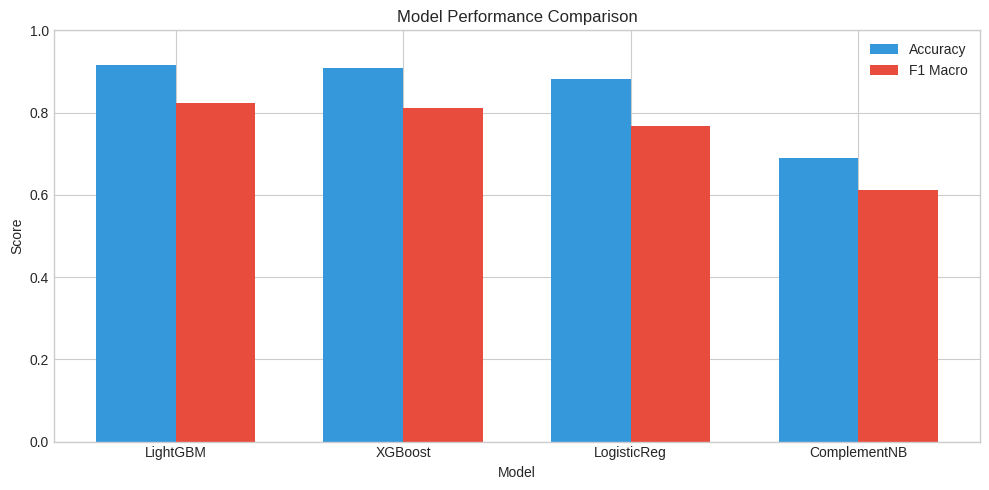

In [17]:
results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
print("\n Model Performance Summary:")
print(results_df.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x + width/2, results_df['f1_macro'], width, label='F1 Macro', color='#e74c3c')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [18]:
print(" Searching for optimal ensemble weights...")

best_f1 = 0
best_weights = None

# Grid search over weight combinations
for w1 in [0.3, 0.4, 0.5]:
    for w2 in [0.2, 0.3, 0.4]:
        for w3 in [0.1, 0.15, 0.2]:
            w4 = 1 - w1 - w2 - w3
            if w4 > 0 and w4 < 0.3:
                ensemble_proba = (w1 * lgb_proba_val + w2 * xgb_proba_val + 
                                  w3 * lr_proba_val + w4 * nb_proba_val)
                ensemble_preds = ensemble_proba.argmax(axis=1)
                f1 = f1_score(y_val, ensemble_preds, average='macro')
                if f1 > best_f1:
                    best_f1 = f1
                    best_weights = (w1, w2, w3, w4)

print(f"\n Best weights found:")
print(f"   LightGBM: {best_weights[0]:.2f}")
print(f"   XGBoost:  {best_weights[1]:.2f}")
print(f"   LogReg:   {best_weights[2]:.2f}")
print(f"   CompNB:   {best_weights[3]:.2f}")
print(f"   Ensemble F1 Macro: {best_f1:.5f}")

# Final ensemble predictions on validation
ensemble_proba_val = (best_weights[0] * lgb_proba_val + best_weights[1] * xgb_proba_val + 
                      best_weights[2] * lr_proba_val + best_weights[3] * nb_proba_val)
ensemble_preds_val = ensemble_proba_val.argmax(axis=1)

print("\n Final Ensemble Classification Report:")
print(classification_report(y_val, ensemble_preds_val))

 Searching for optimal ensemble weights...

 Best weights found:
   LightGBM: 0.40
   XGBoost:  0.20
   LogReg:   0.10
   CompNB:   0.30
   Ensemble F1 Macro: 0.82243

 Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.73      0.84      0.78      2388
           2       0.88      0.90      0.89      9366
           3       0.63      0.69      0.66       820

    accuracy                           0.91     29700
   macro avg       0.81      0.84      0.82     29700
weighted avg       0.92      0.91      0.92     29700



In [19]:
print(" Generating final submission...")

# Get predictions from all models on test set
lgb_proba_test = lgb_model.predict(X_test_full)
dtest = xgb.DMatrix(X_test_full)
xgb_proba_test = xgb_model.predict(dtest)
lr_proba_test = lr_model.predict_proba(X_test_full)

# TF-IDF only for NB
X_test_tfidf = hstack([X_test_full[:, :n_tfidf_word], X_test_full[:, n_tfidf_word:n_tfidf_word+n_tfidf_char]])
nb_proba_test = nb_model.predict_proba(X_test_tfidf)

# Ensemble predictions
final_proba = (best_weights[0] * lgb_proba_test + 
               best_weights[1] * xgb_proba_test + 
               best_weights[2] * lr_proba_test + 
               best_weights[3] * nb_proba_test)
final_preds = final_proba.argmax(axis=1)

print(f"\n Using 4-Model Ensemble:")
print(f"   Weights: LGB={best_weights[0]:.2f}, XGB={best_weights[1]:.2f}, LR={best_weights[2]:.2f}, NB={best_weights[3]:.2f}")


submission = sample_data.copy()
submission['label'] = final_preds
submission.to_csv('submission.csv', index=False)

print(f"\n Saved: {submission.shape[0]:,} rows to submission.csv")
print("\n Label distribution in submission:")
print(submission['label'].value_counts().sort_index())
submission.head()

 Generating final submission...

 Using 4-Model Ensemble:
   Weights: LGB=0.40, XGB=0.20, LR=0.10, NB=0.30

 Saved: 102,000 rows to submission.csv

 Label distribution in submission:
label
0    56649
1     9288
2    33026
3     3037
Name: count, dtype: int64


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
